In [1]:
import sys
sys.path.append("../..")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch
import networkx as nx
from scipy.stats import gaussian_kde, t

import torch
import torch.nn as nn
import torch.nn.functional as F

import torch_geometric as pyg
from torch_geometric.utils import from_networkx
from torch_geometric.datasets import TUDataset

import GNNInterpreter
from GNNInterpreter.gnninterpreter import *

from utils import mutag_helper
from egg_models.egg_generic_losses import GEDasMatchLoss
import pygmtools as pygm

from gnn_xai_common.models import GCNClassifier

/opt/miniconda/envs/egg-env-38/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/miniconda/envs/egg-env-38/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/opt/miniconda/envs/egg-env-38/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


# Data Prep

/repo/gnn-xai-common/gnn_xai_common/datasets/base_graph_dataset.py:35: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(self.processed_paths[0])
/tmp/ipyker

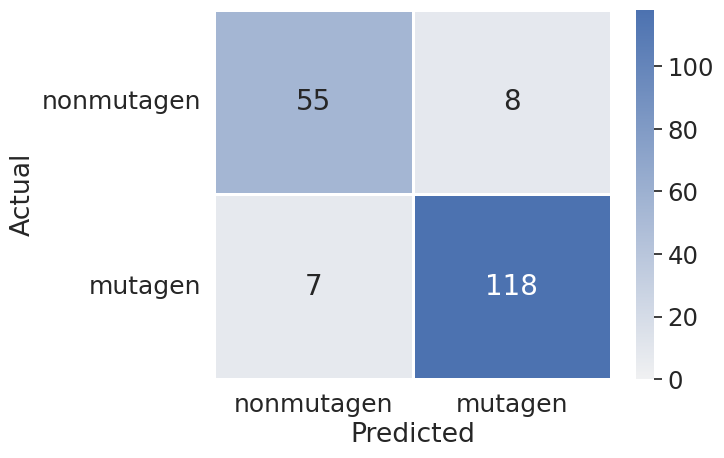

/opt/miniconda/envs/egg-env-38/lib/python3.10/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


In [2]:
# Load dataset.
dataset = MUTAGDataset(data_root = "./data/TUDataset")

# Explainee model.
model = GCNClassifier(node_features=len(dataset.NODE_CLS),
                      num_classes=len(dataset.GRAPH_CLS),
                      hidden_channels=64,
                      num_layers=3)
model.load_state_dict(torch.load('../../GNNInterpreter/ckpts/mutag.pt'))

dataset_list_gt = dataset.split_by_class()
dataset_list_pred = dataset.split_by_pred(model)

evaluation = dataset.model_evaluate(model)
evaluation

draw_matrix(evaluation['cm'], dataset.GRAPH_CLS.values(), fmt='d')

# Extract embeddings. 
mean_embeds = [d.model_transform(model, key="embeds").mean(dim=0) for d in dataset_list_gt]

In [19]:
def run_GNNInterpreter(cls_idx):
    trainer = Trainer(
        sampler=(s := GraphSampler(
            max_nodes=20,
            num_node_cls=len(dataset.NODE_CLS),
            num_edge_cls=len(dataset.EDGE_CLS), 
            temperature=0.15,
            learn_node_feat=True,
            learn_edge_feat=True, 
        )),
        discriminator=model,
        criterion=WeightedCriterion([
            dict(key="logits", criterion=ClassScoreCriterion(class_idx=cls_idx, mode='maximize'), weight=1),
            dict(key="embeds", criterion=EmbeddingCriterion(target_embedding=mean_embeds[cls_idx]), weight=50),
            dict(key="logits", criterion=MeanPenalty(), weight=0),
            dict(key="omega", criterion=NormPenalty(order=1), weight=1),
            dict(key="omega", criterion=NormPenalty(order=2), weight=1),
            dict(key="xi", criterion=NormPenalty(order=1), weight=0),
            dict(key="xi", criterion=NormPenalty(order=2), weight=0),
            # dict(key="eta", criterion=NormPenalty(order=1), weight=0),
            # dict(key="eta", criterion=NormPenalty(order=2), weight=0),
            dict(key="theta_pairs", criterion=KLDivergencePenalty(binary=True), weight=4),
        ]),
        optimizer=(o := torch.optim.SGD(s.parameters(), lr=1)),
        scheduler=torch.optim.lr_scheduler.ExponentialLR(o, gamma=1),
        dataset=dataset,
        budget_penalty=BudgetPenalty(budget=10, order=2, beta=1),
    )

    trainer.train(
        iterations=2000,
        target_probs={cls_idx: (0.9, 1.0)},
        target_size=30,
        w_budget_init=0.5,
        w_budget_inc=1.1,
        w_budget_dec=0.95,
        k_samples=32
    )

    example = trainer.evaluate(threshold=0.5)

    # Covert to typically pyg MUTAG format.  
    example = from_networkx(example)
    example.x = F.one_hot(example.label, num_classes=7).float()
    example.edge_attr = F.one_hot(example.edge_label, num_classes=4).float()
    example.y = torch.tensor(cls_idx).float()
    
    return example 

In [4]:
def get_GNNInterpreter_out(n_samples, cls_idx):
    out = []
    for i in range(n_samples): 
        out.append(run_GNNInterpreter(cls_idx=cls_idx))
    
    return out

# Applying EGG Metrics

## Raw Data

In [5]:
# Raw data

# Download data. 
data_raw = TUDataset(root='data/TUDataset', name='MUTAG')

# Shuffle
data_raw = data_raw.shuffle()

# Split 
train_data = data_raw[:150]
test_data = data_raw[150:]

# Create data lists
train_data_list = []
train_data_list_0 = []
train_data_list_1 = []
test_data_list = []
test_data_list_0 = []
test_data_list_1 = []

for graph in train_data:
    train_data_list.append(graph)

    if graph.y.item() == 0: 
        train_data_list_0.append(graph)

    elif graph.y.item() == 1: 
        train_data_list_1.append(graph)

for graph in test_data:
    test_data_list.append(graph)

    if graph.y.item() == 0: 
        test_data_list_0.append(graph)

    elif graph.y.item() == 1: 
        test_data_list_1.append(graph)

## Meta-Data

In [6]:
node_types = ['C', 'N', 'O', 'F', "I", "Cl", 'Br']
edge_types = ['aromatic', 'single', 'double', 'triple']
color_palette = np.array(['orange', 'magenta', 'green', 'blue', 'cyan', 'red', 'lime'])
color_palette_dropped = np.array(['orange', 'magenta', 'green', 'blue', 'red'])

## Helper Functions

In [7]:
def t_confidence_interval(data):
    mean = np.mean(data)
    std_dev = np.std(data)

    print(f"Mean {mean} SD: {std_dev}")

    n = len(data)
    t_value = t.ppf(0.975, df=n-1) 
    margin_of_error = t_value * (std_dev / np.sqrt(n))
    lower_bound = np.round(mean - margin_of_error, 4)
    upper_bound = np.round(mean + margin_of_error, 4)

    print(f"({lower_bound}, {upper_bound})")

In [8]:
def GED_interval_gnnInterp(
    cls_idx: int, 
    obs_data: list,     
    GED_fn: torch.nn.Module,  
    batch_size=16 
):
    out = []
    for i in range(batch_size):
        out.append(run_GNNInterpreter(cls_idx))
    out_batch = pyg.data.Batch.from_data_list(out) 
    
    loader = pyg.loader.DataLoader(
        obs_data, batch_size=batch_size, drop_last=True
    )

    running_GED = []
    for batch in loader: 
        out_egg = mutag_helper.ex_to_egg(out_batch)
        obs_egg = mutag_helper.ex_to_egg(batch)

        egg_sizes = torch.tensor([
            graph.x.shape[0] + graph.edge_index.shape[1] 
            for graph in out
        ])

        loss = (
            GED_fn(*out_egg, *obs_egg) / 
            egg_sizes
        ).mean()

        running_GED.append(min(loss.item(), 1.0))

    t_confidence_interval(running_GED)

In [9]:
GED_fn = GEDasMatchLoss(
    node_size=20, 
    cont_node_indices=None, 
    cont_edge_indices=None, 
    dis_node_indices=(slice(0, 7), ),  
    dis_edge_indices=(slice(0, 4), 4), 
    QAP_solver=pygm.ngm, 
)

In [22]:
def vis_con_graph(
    gen_ex: pyg.data, 
    obs_ex1: pyg.data, 
    obs_ex2: pyg.data, 
    GED_fn, 
    explainee, 
    cls_idx: int
) -> None:

    # Convert to egg format to compute GED.
    gen_egg = mutag_helper.ex_to_egg(
        pyg.data.Batch().from_data_list([gen_ex])
    )
    obs_egg1 = mutag_helper.ex_to_egg(
        pyg.data.Batch().from_data_list([obs_ex1])
    )
    obs_egg2 = mutag_helper.ex_to_egg(
        pyg.data.Batch().from_data_list([obs_ex2])
    )

    # Compute GED. 
    # egg_size = torch.tensor(gen_ex.x.shape[0] + gen_ex.edge_index.shape[1])
    # GED_percent = GED_fn(*gen_egg, *obs_egg) / egg_size
    
    # Create networkx graphs for plotting. 
    colors0 = color_palette[torch.argmax(gen_ex.x, dim=-1).cpu().numpy()]
    gen_nx = pyg.utils.to_networkx(gen_ex)

    colors1 = color_palette[torch.argmax(obs_ex1.x, dim=-1).cpu().numpy()]
    obs_nx = pyg.utils.to_networkx(obs_ex1)

    colors2 = color_palette[torch.argmax(obs_ex2.x, dim=-1).cpu().numpy()]
    obs_nx2 = pyg.utils.to_networkx(obs_ex2)
   
    with torch.no_grad():
        aff_mat = GED_fn.get_aff_mat(*gen_egg, *obs_egg1)
        dis_match_mat = GED_fn.get_dis_match_mat(aff_mat)

    with torch.no_grad():
        aff_mat2 = GED_fn.get_aff_mat(*gen_egg, *obs_egg2)
        dis_match_mat2 = GED_fn.get_dis_match_mat(aff_mat2)

    egg_size = torch.tensor([
        gen_ex.x.shape[0] + gen_ex.edge_index.shape[1] 
    ])

    GED_score1 = (
        -1 * pygm.utils.compute_affinity_score(dis_match_mat, aff_mat) / 
        egg_size
    ).item()
    GED_score1 = min(GED_score1, 1.0) # cap at 100% edit.

    GED_score2 = (
        -1 * pygm.utils.compute_affinity_score(dis_match_mat2, aff_mat2) / 
        egg_size
    ).item()
    GED_score2 = min(GED_score2, 1.0)
     
    # pos_1 = nx.spring_layout(obs_nx)
    pos_1 = nx.kamada_kawai_layout(obs_nx)
    # pos_2 = nx.spring_layout(gen_nx)
    #pos_2 = nx.kamada_kawai_layout(gen_nx)
    pos_2 = {}
    for i in range(gen_ex.x.shape[0]):
        j = torch.argmax(dis_match_mat.squeeze()[i]).item()
        pos_2[i] = pos_1[j]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

    nx.draw(obs_nx, node_color=colors1, pos=pos_1, ax=axes[0], arrows=False)

    nx.draw(gen_nx, node_color=colors0, pos=pos_2, ax=axes[1], arrows=False)

    for i in range(gen_ex.x.shape[0]):
        j = torch.argmax(dis_match_mat.squeeze()[i]).item()
        con = ConnectionPatch(xyA=pos_1[j], xyB=pos_2[i], 
                            coordsA="data", coordsB="data",
                            axesA=axes[1], axesB=axes[0], color="green")

        fig.add_artist(con)

    # pos_3 = nx.spring_layout(obs_nx2)
    pos_3 = nx.kamada_kawai_layout(obs_nx2)
    # pos_3 = {}
    # for i in range(gen_ex.x.shape[0]):
        # j = torch.argmax(dis_match_mat2.squeeze()[i]).item()
        # pos_3[j] = pos_2[i]

    nx.draw(obs_nx2, node_color=colors2, pos=pos_3, ax=axes[2], arrows=False)

    for i in range(gen_ex.x.shape[0]):
        j = torch.argmax(dis_match_mat2.squeeze()[i]).item()
        con = ConnectionPatch(xyA=pos_3[j], xyB=pos_2[i], 
                            coordsA="data", coordsB="data",
                            axesA=axes[2], axesB=axes[1], color="blue")

        fig.add_artist(con)
     
    explainee.eval()
    with torch.no_grad():
        pred_gen = explainee(gen_ex)['probs'][0][cls_idx].item()
        pred_obs1 = explainee(obs_ex1)['probs'][0][cls_idx].item()
        pred_obs2 = explainee(obs_ex2)['probs'][0][cls_idx].item()
     
    axes[0].set_title(f"Class Probability: {pred_obs1:0.2f} GED: {GED_score1:0.2f}", fontsize=20)
    axes[1].set_title(f"Class Probability: {pred_gen:0.2f}", fontsize=20)
    axes[2].set_title(f"GED: {GED_score2:0.2f} Class Probability: {pred_obs2:0.2f}", fontsize=20)
        
        
#    print(GED_percent)

In [23]:
def compute_node_probs(
    cls_idx, 
    n_samples = 10, 
):
    nodes = torch.zeros(7)
    for i in range(n_samples):
        gen = run_GNNInterpreter(cls_idx)
        nodes += gen.x.sum(dim=0)
    
    return nodes / nodes.sum()

In [24]:
def compute_edge_probs(
    cls_idx, 
    n_samples = 10, 
):
    edges = torch.zeros(4)
    for i in range(n_samples):
        gen = run_GNNInterpreter(cls_idx)
        edges += gen.edge_attr.sum(dim=0)
    
    return edges / edges.sum()

## GED Intervals

In [25]:
# GED to 1 trained to 1. 
GED_interval_gnnInterp(
    cls_idx=1, obs_data=train_data_list_1, GED_fn=GED_fn, 
    batch_size=16
)

  0%|          | 2/2000 [00:00<05:40,  5.87it/s, size=15.1, bpw=0.55, nonmutagen=-7.03, mutagen=7.01] 


Mean 0.14947239309549332 SD: 0.0027806206289432045
(0.1466, 0.1524)


In [26]:
# GED to 0 trained to 1. 
GED_interval_gnnInterp(
    cls_idx=1, obs_data=train_data_list_0, GED_fn=GED_fn, 
    batch_size=16
)

  0%|          | 1/2000 [00:00<09:46,  3.41it/s, size=29.7, bpw=0.55, nonmutagen=-3.14, mutagen=3.1]


Mean 0.20557859043280283 SD: 0.020608529442076296
(0.1544, 0.2568)


In [28]:
# GED to 0 trained to 0
GED_interval_gnnInterp(
    cls_idx=0, obs_data=train_data_list_0, GED_fn=GED_fn, 
    batch_size=16
)

  0%|          | 2/2000 [00:00<05:17,  6.30it/s, size=17.7, bpw=0.5, nonmutagen=-1.34, mutagen=1.34]


Mean 0.22821738322575888 SD: 0.004950088452178797
(0.2159, 0.2405)


In [29]:
# GED to 1 trained to 0
GED_interval_gnnInterp(
    cls_idx=0, obs_data=train_data_list_1, GED_fn=GED_fn, 
    batch_size=16
)

  0%|          | 3/2000 [00:00<03:57,  8.40it/s, size=7.19, bpw=0.5, nonmutagen=-14.1, mutagen=14]


Mean 0.3747706909974416 SD: 0.003162714095201326
(0.3715, 0.3781)


## Mapped Visuals

  0%|          | 1/2000 [00:00<08:49,  3.77it/s, size=27.3, bpw=0.55, nonmutagen=-1.51, mutagen=1.51]


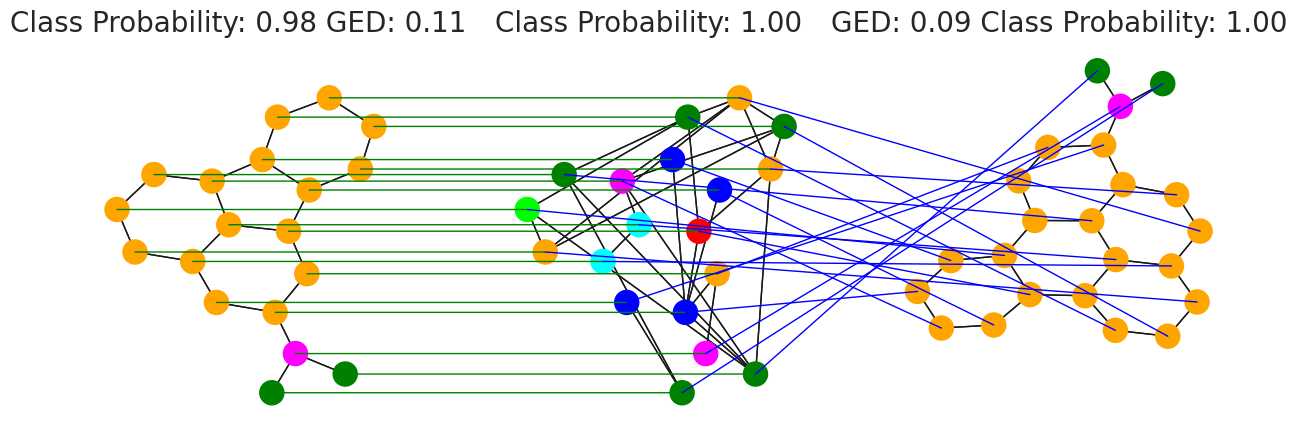

In [30]:
# Mutagen. 
gen_gnnInterp = run_GNNInterpreter(cls_idx=1)
obs_ex1 = test_data_list_1[1]
obs_ex2 = test_data_list_1[5]

vis_con_graph(gen_gnnInterp, obs_ex1, obs_ex2, GED_fn, model, 1)

  0%|          | 1/2000 [00:00<08:59,  3.71it/s, size=27.4, bpw=0.5, nonmutagen=-8.79, mutagen=8.3]


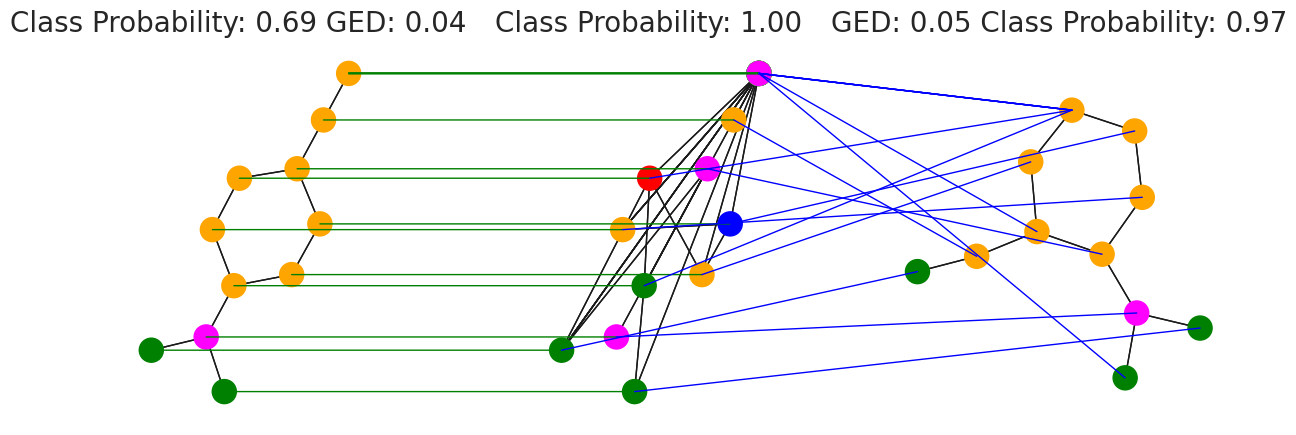

In [34]:
# Nonmutagen.
gen_gnnInterp = run_GNNInterpreter(cls_idx=0)
obs_ex1 = test_data_list_0[1]
obs_ex2 = test_data_list_0[7]

vis_con_graph(gen_gnnInterp, obs_ex1, obs_ex2, GED_fn, model, 0)

## Parameter Probability Plots

  0%|          | 2/2000 [00:00<05:28,  6.09it/s, size=15.8, bpw=0.605, nonmutagen=-7.95, mutagen=7.92]


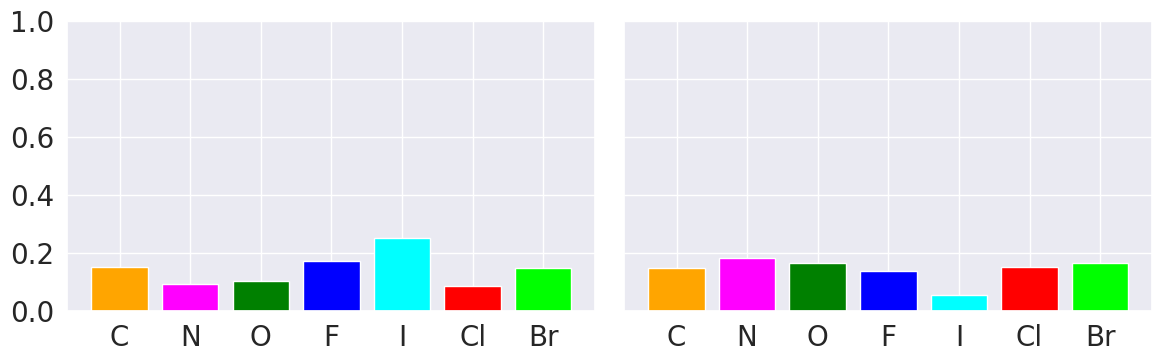

In [167]:
cell_type_probs_0 = compute_node_probs(0, 1000)

cell_type_probs_1 = compute_node_probs(1, 1000)

# cell_type_probs_untrained = torch.softmax(
#     generator_untrained.DisNodeFeats[0].probs, dim=0)
# cell_type_probs_untrained = cell_type_probs_untrained.detach().cpu().numpy()

plot_indices = ['C', 'N', 'O', 'F', "I", "Cl", 'Br']

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[1].bar(plot_indices, cell_type_probs_0, color=color_palette)
axes[0].bar(plot_indices, cell_type_probs_1, color=color_palette)
#axes[2].bar(plot_indices, cell_type_probs_untrained, color=color_palette)

#axes[1].set_title('Nonmutagen', fontsize=20)
#axes[0].set_title('Mutagen', fontsize=20)
#axes[2].set_title('Untrained')

axes[1].tick_params(axis='both', which='major', labelsize=20)
axes[0].tick_params(axis='both', which='major', labelsize=20)

plt.ylim(0, 1)
plt.tight_layout()
plt.show()

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 1/2000 [00:00<09:18,  3.58it/s, size=26.2, bpw=0.55, nonmutagen=-32.1, mutagen=32]


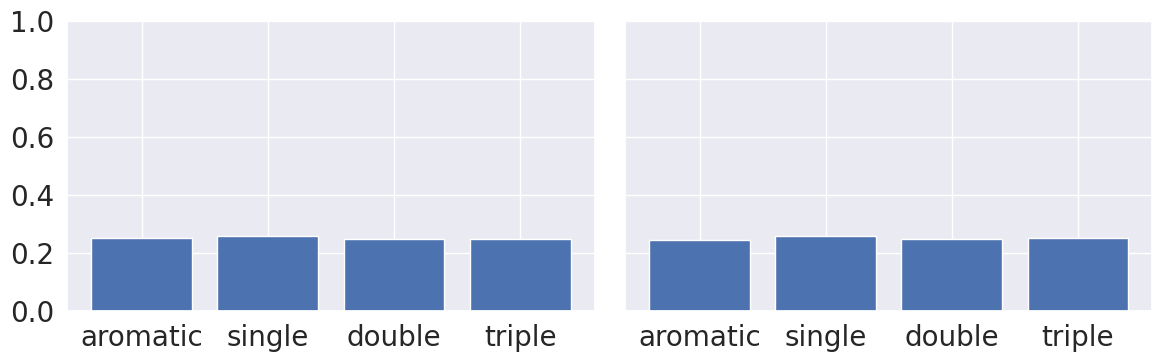

In [166]:
edge_type_probs_0 = compute_edge_probs(0, 1000)

edge_type_probs_1 = compute_edge_probs(1, 1000)

# edge_type_probs_untrained = torch.softmax(
#     generator_untrained.DisEdgeFeats[0].probs, dim=0)
# edge_type_probs_untrained = edge_type_probs_untrained.detach().cpu().numpy()

plot_indices = ['aromatic', 'single', 'double', 'triple']

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[1].bar(plot_indices, edge_type_probs_0)
axes[0].bar(plot_indices, edge_type_probs_1)
#axes[2].bar(plot_indices, edge_type_probs_untrained)

#axes[1].set_title('Nonmutagen')
#axes[0].set_title('Mutagen')
#axes[2].set_title('Untrained')

axes[1].tick_params(axis='both', which='major', labelsize=20)
axes[0].tick_params(axis='both', which='major', labelsize=20)

plt.ylim(0, 1)
plt.tight_layout()
plt.show()